# Provider Access Gap Analysis
**ASA DataFest 2026 — Stormont Vail Health**

---

> **Note:** This notebook requires pre-geocoded provider data (`prov_map_clean.csv`).

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.neighbors import BallTree
import folium
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'figure.facecolor': 'white'})

BLUE = '#378ADD'
RED  = '#E24B4A'
print('Setup complete')


Setup complete


## 1. Load Data

In [2]:
diag          = pd.read_csv('../data/diagnosis.csv')
enct          = pd.read_csv('../data/encounters.csv')
pat           = pd.read_csv('../data/patients.csv')
tiger         = pd.read_csv('../data/tigercensuscodes.csv', dtype={'GEOID': str})
prov_map_clean = pd.read_csv('../data/prov_map_clean.csv')

pat['CensusBlockGroupFipsCode'] = pat['CensusBlockGroupFipsCode'].astype(str)
print(f'providers geocoded: {prov_map_clean.shape}')


providers geocoded: (1310, 12)


## 2. Build Census Block Patient Aggregation

In [3]:
diag_unique = diag[['DiagnosisKey','GroupCode']].drop_duplicates()
diag_unique['first_char'] = (
    diag_unique['GroupCode'].str.replace(r'^ICD-10-CM: ', '', regex=True).str[0]
)

enct_pat = (
    enct
    .merge(pat, left_on='PatientDurableKey', right_on='DurableKey', how='left')
    .merge(diag_unique, left_on='PrimaryDiagnosisKey', right_on='DiagnosisKey', how='left')
    .merge(tiger, left_on='CensusBlockGroupFipsCode', right_on='GEOID', how='left')
)

map_data = (
    enct_pat
    .dropna(subset=['CENTLAT','CENTLON','PopulationValue'])
    .groupby(['CensusBlockGroupFipsCode','CENTLAT','CENTLON'])
    .agg(population=('PopulationValue','first'),
         n_patients=('PatientDurableKey','nunique'))
    .reset_index()
)
print(f'Census blocks with patients: {len(map_data)}')


Census blocks with patients: 1247


## 3. Patient Distribution Map

In [4]:
def pop_color(pop):
    if pop >= 2000: return '#042C53'
    if pop >= 1000: return '#185FA5'
    return '#B5D4F4'

center = [map_data['CENTLAT'].mean(), map_data['CENTLON'].mean()]
m = folium.Map(location=center, zoom_start=9, tiles='CartoDB positron')

for _, row in map_data.iterrows():
    folium.CircleMarker(
        location=[row['CENTLAT'], row['CENTLON']],
        radius=max(1, np.sqrt(row['population']) * 0.3),
        color=pop_color(row['population']),
        fill=True, fill_opacity=0.5, weight=0.5,
        popup=f"FIPS: {row['CensusBlockGroupFipsCode']}<br>"
              f"Population: {row['population']:,.0f}<br>"
              f"Patients: {row['n_patients']:,}"
    ).add_to(m)

m


## 4. Population-Weighted DBSCAN Clustering

In [5]:
# Expand rows proportional to population (1 rep per 500 people)
map_valid = map_data.dropna(subset=['CENTLAT','CENTLON','population'])
map_valid = map_valid.assign(weight=lambda d: np.ceil(d['population']/500).astype(int))
expanded  = map_valid.loc[map_valid.index.repeat(map_valid['weight'])][['CENTLON','CENTLAT']]

# DBSCAN in radians for haversine metric
coords_rad = np.radians(expanded[['CENTLAT','CENTLON']].values)
eps_rad    = 0.05 / 6371  # ~5km in radians
db         = DBSCAN(eps=eps_rad, min_samples=10, algorithm='ball_tree', metric='haversine')
labels     = db.fit_predict(coords_rad)

map_valid2 = map_valid.copy()
map_valid2 = map_valid2.loc[map_valid2.index.repeat(map_valid2['weight'])].copy()
map_valid2['cluster'] = labels

# Collapse back to block level
map_clustered = (
    map_valid2.groupby(['CENTLON','CENTLAT'])
    .agg(cluster=('cluster','first'),
         population=('population', lambda x: len(x) * 500))
    .reset_index()
)

# Cluster centroids (weighted mean)
cluster_centers = (
    map_clustered[map_clustered['cluster'] != -1]
    .groupby('cluster')
    .apply(lambda d: pd.Series({
        'CENTLAT':    np.average(d['CENTLAT'], weights=d['population']),
        'CENTLON':    np.average(d['CENTLON'], weights=d['population']),
        'population': d['population'].sum(),
        'n_blocks':   len(d)
    }))
    .reset_index()
    .query('population >= 5000')
)
print(f'Clusters with population >= 5000: {len(cluster_centers)}')


Clusters with population >= 5000: 3


## 5. Assign Providers to Nearest Cluster

In [6]:
prov_valid = prov_map_clean.dropna(subset=['CENTLAT','CENTLON']).copy()

# BallTree KNN in radians
cluster_rad = np.radians(cluster_centers[['CENTLAT','CENTLON']].values)
prov_rad    = np.radians(prov_valid[['CENTLAT','CENTLON']].values)

tree    = BallTree(cluster_rad, metric='haversine')
_, idxs = tree.query(prov_rad, k=1)

prov_valid = prov_valid.copy()
prov_valid['cluster'] = cluster_centers.iloc[idxs.flatten()]['cluster'].values

provider_counts = prov_valid.groupby('cluster').size().reset_index(name='n_providers')

# Final cluster summary
cluster_summary = (
    cluster_centers
    .merge(provider_counts, on='cluster', how='left')
    .assign(
        n_providers=lambda d: d['n_providers'].fillna(0).astype(int),
        patients_per_provider=lambda d: d['population'] / d['n_providers'].replace(0, np.nan),
        has_gap=lambda d: (d['patients_per_provider'] > 3500) | d['patients_per_provider'].isna(),
        gap_label=lambda d: d['has_gap'].map({True: 'Access gap', False: 'Adequate'})
    )
)
print(f"Access gaps: {cluster_summary['has_gap'].sum()} / {len(cluster_summary)} clusters")


Access gaps: 0 / 3 clusters


## 6. Access Gap Bar Chart

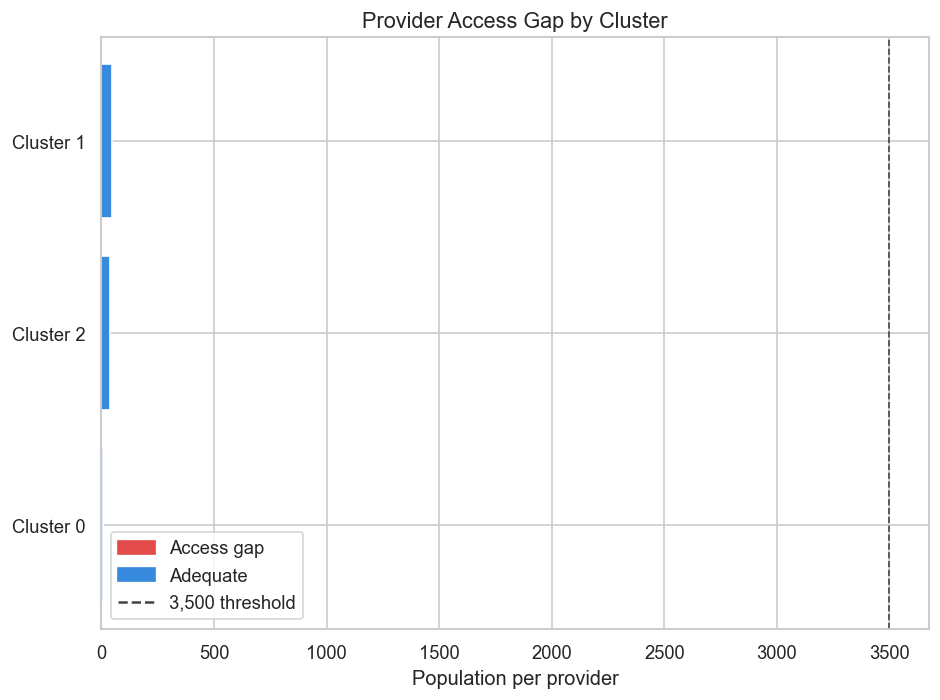

In [7]:
plot_df = cluster_summary.dropna(subset=['patients_per_provider']).sort_values('patients_per_provider')

fig, ax = plt.subplots(figsize=(8, 6))
colors = [RED if g else BLUE for g in plot_df['has_gap']]
ax.barh([f'Cluster {c}' for c in plot_df['cluster']], plot_df['patients_per_provider'], color=colors)
ax.axvline(3500, color='#444441', linestyle='--', linewidth=1, label='3,500 threshold')
ax.set(xlabel='Population per provider', title='Provider Access Gap by Cluster')
ax.legend()
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=RED, label='Access gap'),
    Patch(color=BLUE, label='Adequate'),
    plt.Line2D([0],[0], color='#444441', linestyle='--', label='3,500 threshold')
])
plt.tight_layout(); plt.show()


## 7. Interactive Access Gap Map

In [8]:
m2 = folium.Map(location=[cluster_summary['CENTLAT'].mean(),
                           cluster_summary['CENTLON'].mean()],
                zoom_start=8, tiles='CartoDB positron')

for _, row in cluster_summary.iterrows():
    color = RED if row['has_gap'] else BLUE
    radius = max(5, np.sqrt(row['population']) * 0.4)
    ppp = 'No providers' if pd.isna(row['patients_per_provider']) \
          else f"{row['patients_per_provider']:,.0f}"
    folium.CircleMarker(
        location=[row['CENTLAT'], row['CENTLON']],
        radius=radius,
        color=color, fill=True, fill_opacity=0.75, weight=0.5,
        popup=(
            f"<b>Cluster:</b> {int(row['cluster'])}<br>"
            f"<b>Status:</b> {row['gap_label']}<br>"
            f"<b>Population:</b> {row['population']:,.0f}<br>"
            f"<b>Providers:</b> {row['n_providers']}<br>"
            f"<b>Pop/provider:</b> {ppp}"
        )
    ).add_to(m2)

m2


## 8. Diagnosis Patterns in Gap vs. Non-Gap Areas

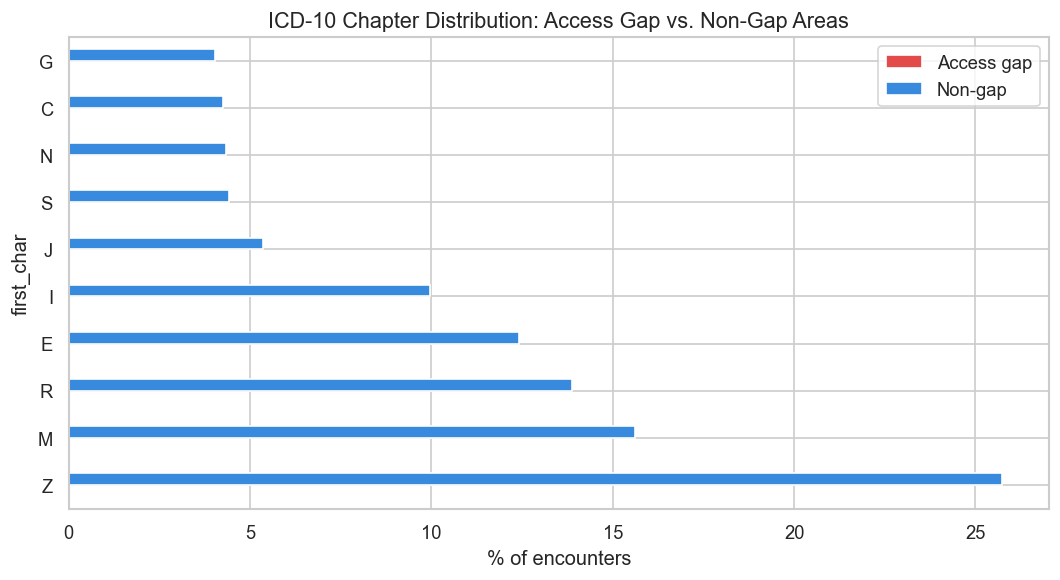

In [9]:
gap_clusters = set(cluster_summary[cluster_summary['has_gap']]['cluster'])

# Map blocks to clusters
block_cluster = map_clustered[['CENTLON','CENTLAT','cluster']].drop_duplicates()
enct_clustered = enct_pat.merge(
    map_data[['CensusBlockGroupFipsCode','CENTLAT','CENTLON']],
    on=['CENTLAT','CENTLON'], how='left', suffixes=('','_map')
).merge(block_cluster, on=['CENTLON','CENTLAT'], how='left')

enct_gap     = enct_clustered[enct_clustered['cluster'].isin(gap_clusters)]
enct_non_gap = enct_clustered[~enct_clustered['cluster'].isin(gap_clusters)]

top_chars = (
    pd.concat([enct_gap, enct_non_gap])['first_char']
    .value_counts().head(10).index.tolist()
)

def chapter_pct(df, group_name, chars):
    d = df[df['first_char'].isin(chars)]
    counts = d['first_char'].value_counts().reindex(chars, fill_value=0)
    return (counts / counts.sum() * 100).rename(group_name)

diag_compare = pd.DataFrame({
    'Access gap': chapter_pct(enct_gap, 'Access gap', top_chars),
    'Non-gap':    chapter_pct(enct_non_gap, 'Non-gap', top_chars),
})

diag_compare.plot(kind='barh', figsize=(9,5), color=[RED, BLUE])
plt.xlabel('% of encounters')
plt.title('ICD-10 Chapter Distribution: Access Gap vs. Non-Gap Areas')
plt.tight_layout(); plt.show()


## 9. Single-Visit Chronic Patients in Gap Areas

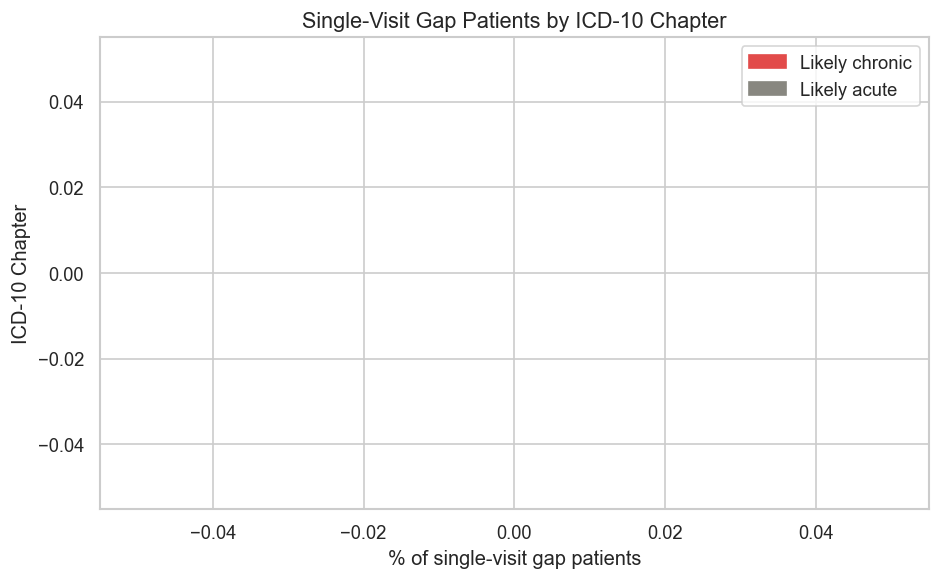

In [10]:
def get_visit_counts(df):
    return df.groupby('PatientDurableKey').size().reset_index(name='n_visits')

gap_visits = get_visit_counts(enct_gap)
single_gap = enct_gap[enct_gap['PatientDurableKey'].isin(
    gap_visits[gap_visits['n_visits']==1]['PatientDurableKey']
)]

chronic_codes = list('EMINQGFK')

single_gap_diag = (
    single_gap['first_char'].value_counts(normalize=True)
    .mul(100).reset_index()
)
single_gap_diag.columns = ['first_char','pct']
single_gap_diag['likely_chronic'] = single_gap_diag['first_char'].isin(chronic_codes)
single_gap_diag = single_gap_diag.dropna().head(15)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [RED if c else '#888780' for c in single_gap_diag['likely_chronic']]
ax.barh(single_gap_diag['first_char'], single_gap_diag['pct'], color=colors)
ax.set(xlabel='% of single-visit gap patients',
       title='Single-Visit Gap Patients by ICD-10 Chapter',
       ylabel='ICD-10 Chapter')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=RED, label='Likely chronic'),
    Patch(color='#888780', label='Likely acute')
])
plt.tight_layout(); plt.show()
